# Task-2 Unemployment Analysis with Python

## Objective: 
Perform exploratory data analysis on unemployment data to uncover regional and temporal trends, with a focus on the impact of the COVID-19 pandemic on unemployment rates in India.


In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Load The Dataset

In [156]:
data=pd.read_csv('Unemployment in India.csv')
data

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Understanding

In [157]:
data.shape

(768, 7)

In [158]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [159]:
data.columns = data.columns.str.strip()

In [160]:
print(data.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [173]:
data['Date'] = pd.to_datetime(
    data['Date'].str.strip(),
    dayfirst=True,
    errors='coerce'
)

In [175]:
print(data['Date'].head())
print(data['Date'].dtype)

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[us]
datetime64[us]


In [162]:
data.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [163]:
data.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [164]:
print("No. of duplicate values:",data.duplicated().sum())

No. of duplicate values: 27


In [165]:
data.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [166]:
data=data.dropna()

In [167]:
data.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

## Visualization

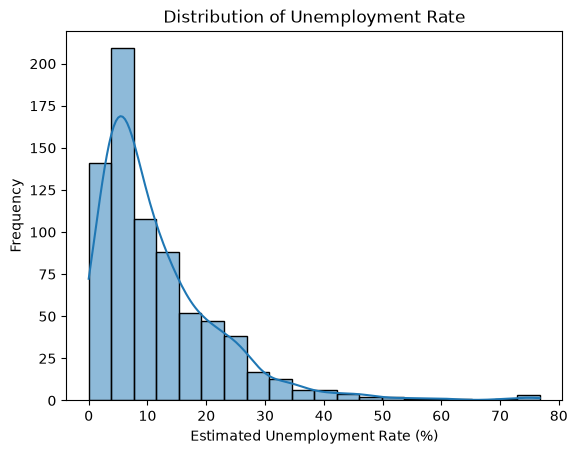

In [177]:
sns.histplot(data['Estimated Unemployment Rate (%)'], bins=20, kde=True)
plt.title('Distribution of Unemployment Rate')
plt.xlabel('Estimated Unemployment Rate (%)')
plt.ylabel('Frequency')
plt.show()

The histogram shows that most unemployment rates are concentrated between 5% and 10%, indicating that the majority of observations experienced relatively low unemployment. The distribution is positively (right) skewed, with only a few observations having very high unemployment rates, which may represent exceptional situations or outliers.

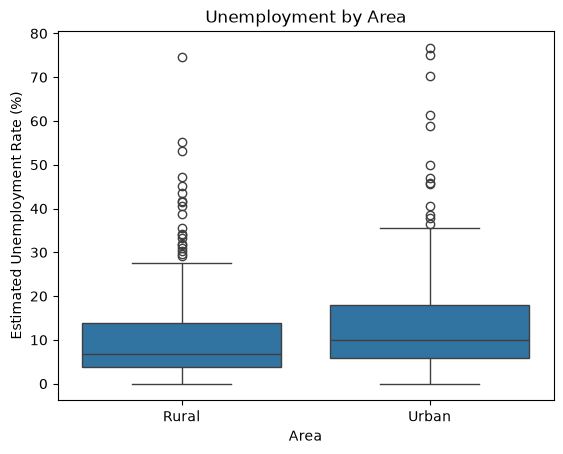

In [ ]:
sns.boxplot(x='Area', y=' Estimated Unemployment Rate (%)', data=data)

plt.title("Unemployment by Area")
plt.xlabel("Area")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.show()

The boxplot shows that Urban areas have a higher median unemployment rate compared to Rural areas. It also indicates greater variation in unemployment rates across Urban regions. Several outliers are present in both categories, suggesting that a few regions experienced exceptionally high unemployment rates.

In [179]:
data.sort_values(by='Estimated Unemployment Rate (%)', ascending=False, inplace=True)
data['Estimated Unemployment Rate (%)']

627    76.74
628    75.00
242    74.51
531    70.17
530    61.48
       ...  
231     0.00
618     0.00
51      0.00
77      0.00
25      0.00
Name: Estimated Unemployment Rate (%), Length: 740, dtype: float64

In [180]:
top_10_states = (data.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10))

In [181]:
top_10_states

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

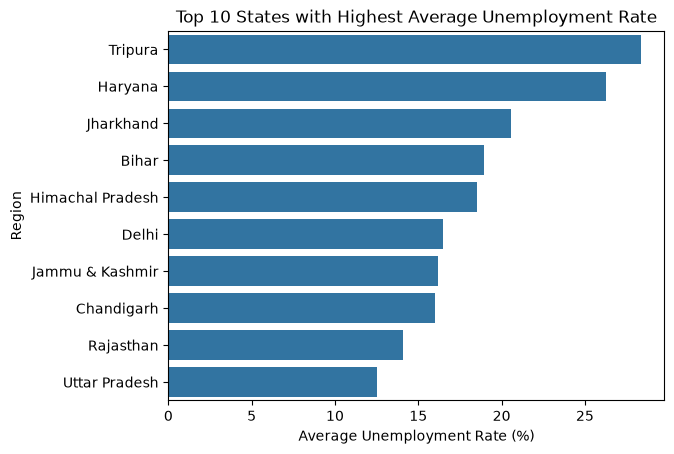

In [182]:
#plt.figure(figsize=(10,6))

sns.barplot(
    x=top_10_states.values,
    y=top_10_states.index
)

plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.show()

### Observation 
- The bar chart represents the top 10 states with the highest average unemployment rates. 
- Tripura recorded the highest average unemployment rate, followed by Haryana and Jharkhand. 
- These states consistently experienced higher unemployment during the observed period, indicating greater employment challenges compared to other regions.

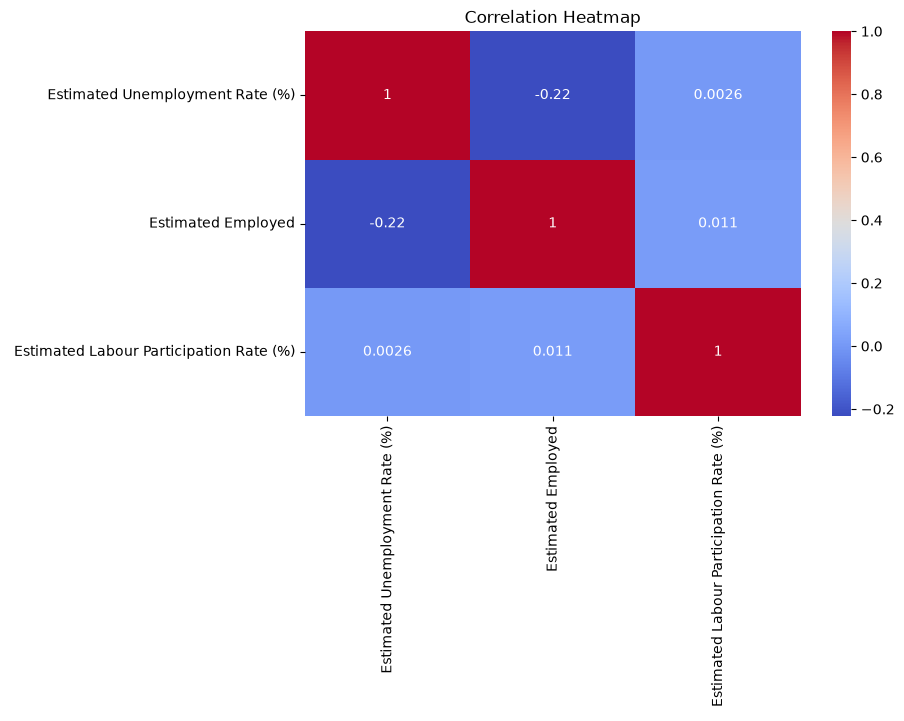

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [189]:
states = ['Delhi', 'Maharashtra', 'Karnataka']

In [190]:
states_data = data[data['Region'].isin(states)]

<Axes: xlabel='Date', ylabel='Estimated Unemployment Rate (%)'>

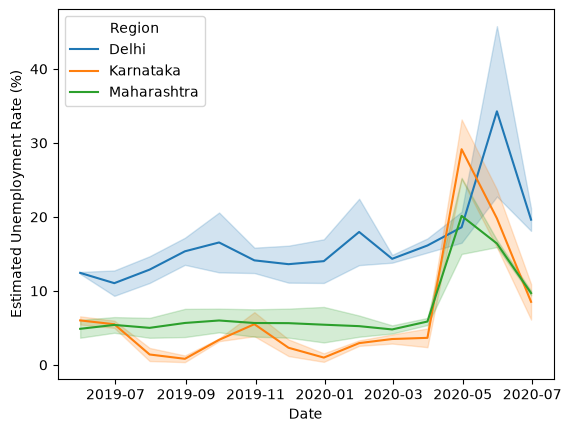

In [191]:
sns.lineplot(data=states_data, x='Date', y='Estimated Unemployment Rate (%)', hue='Region')

The unemployment trend varied across the selected states. All three states experienced noticeable changes during the COVID-19 period, though the impact differed from one state to another.

In [185]:
pre = data[data['Date'] < '2020-03-01']
post= data[data['Date'] >= '2020-03-01']

In [187]:
comparison = pd.DataFrame({
    "Period":["Pre-COVID","Post-COVID"],
    "Average Unemployment Rate":[
        pre["Estimated Unemployment Rate (%)"].mean(),
        post["Estimated Unemployment Rate (%)"].mean()
    ]
})

<Axes: xlabel='Period', ylabel='Average Unemployment Rate'>

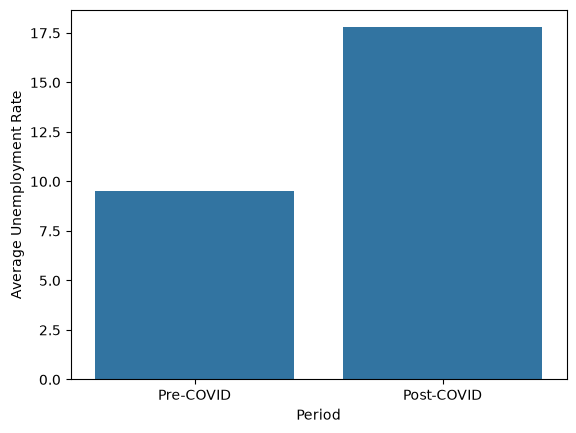

In [188]:
sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment Rate"
)


The average unemployment rate increased significantly during the post-COVID period, highlighting the economic impact of the pandemic.

### Conclusion
This project analyzed unemployment trends in India using Python. After cleaning the data and performing exploratory data analysis (EDA), several visualizations were created to identify patterns across regions, areas, and time. The analysis revealed variations in unemployment rates among different states and showed a significant increase during 2020. Overall, this project demonstrates how Python can be used to clean, analyze, and visualize real-world datasets to generate meaningful insights.